In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from scipy.stats import chi2
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [121]:
df = pd.read_excel("wine.xlsx")
df.head()

,INDEX,Purchase,Cases,STARS,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex
0,1,1,3,2,3.2,1.160,-0.98,54.2,-0.567,,268,0.99280,3.33,-0.59,9.9,0,8
1,2,1,3,3,4.5,0.160,-0.81,26.1,-0.425,15,-327,1.02792,3.38,0.7,,-1,7
2,4,1,5,3,7.1,2.640,-0.88,14.8,0.037,214,142,0.99518,3.12,0.48,22,-1,8
3,5,1,3,1,5.7,0.385,0.04,18.8,-0.425,22,115,0.99640,2.24,1.83,6.2,-1,6
4,6,1,4,2,8.0,0.330,-1.26,9.4,,-167,108,0.99457,3.12,1.77,13.7,0,9


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12795 entries, 0 to 12794
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INDEX               12795 non-null  int64  
 1   Purchase            12795 non-null  int64  
 2   Cases               12795 non-null  int64  
 3   STARS               12795 non-null  object 
 4   FixedAcidity        12795 non-null  float64
 5   VolatileAcidity     12795 non-null  float64
 6   CitricAcid          12795 non-null  float64
 7   ResidualSugar       12795 non-null  object 
 8   Chlorides           12795 non-null  object 
 9   FreeSulfurDioxide   12795 non-null  object 
 10  TotalSulfurDioxide  12795 non-null  object 
 11  Density             12795 non-null  float64
 12  pH                  12795 non-null  object 
 13  Sulphates           12795 non-null  object 
 14  Alcohol             12795 non-null  object 
 15  LabelAppeal         12795 non-null  int64  
 16  Acid

In [122]:
df = df.drop(columns = ["INDEX"])

In [123]:
df["STARS"] = pd.to_numeric(df["STARS"], errors = "coerce")
df["ResidualSugar"] = pd.to_numeric(df["ResidualSugar"], errors = "coerce")
df["Chlorides"] = pd.to_numeric(df["Chlorides"], errors = "coerce")
df["FreeSulfurDioxide"] = pd.to_numeric(df["FreeSulfurDioxide"], errors = "coerce")
df["TotalSulfurDioxide"] = pd.to_numeric(df["TotalSulfurDioxide"], errors = "coerce")
df["pH"] = pd.to_numeric(df["pH"], errors = "coerce")
df["Sulphates"] = pd.to_numeric(df["Sulphates"], errors = "coerce")
df["Alcohol"] = pd.to_numeric(df["Alcohol"], errors = "coerce")


In [92]:
#Missing Value Check
df.isna().sum().sort_values(ascending = False)

STARS                 3359
Sulphates             1210
TotalSulfurDioxide     682
Alcohol                653
FreeSulfurDioxide      647
Chlorides              638
ResidualSugar          616
pH                     395
Purchase                 0
Cases                    0
FixedAcidity             0
VolatileAcidity          0
CitricAcid               0
Density                  0
LabelAppeal              0
AcidIndex                0
dtype: int64

In [74]:
#Percentage of Missing Values
(df.isna().mean()*100).sort_values(ascending=False)

STARS                 26.252442
Sulphates              9.456819
TotalSulfurDioxide     5.330207
Alcohol                5.103556
FreeSulfurDioxide      5.056663
Chlorides              4.986323
ResidualSugar          4.814381
pH                     3.087143
Purchase               0.000000
Cases                  0.000000
FixedAcidity           0.000000
VolatileAcidity        0.000000
CitricAcid             0.000000
Density                0.000000
LabelAppeal            0.000000
AcidIndex              0.000000
dtype: float64

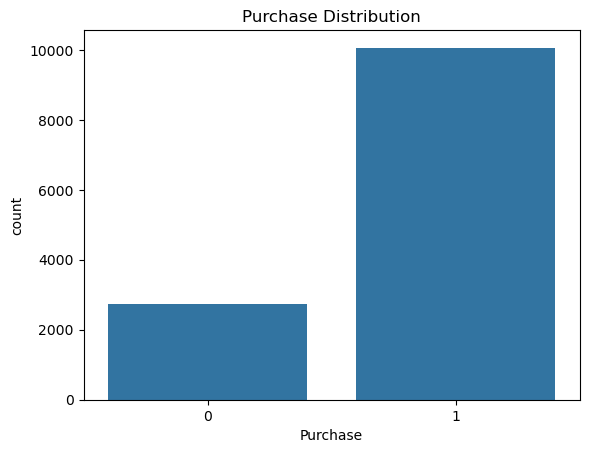

In [52]:
#Purchase distribution
sns.countplot(x="Purchase", data=df)
plt.title("Purchase Distribution")
plt.show()

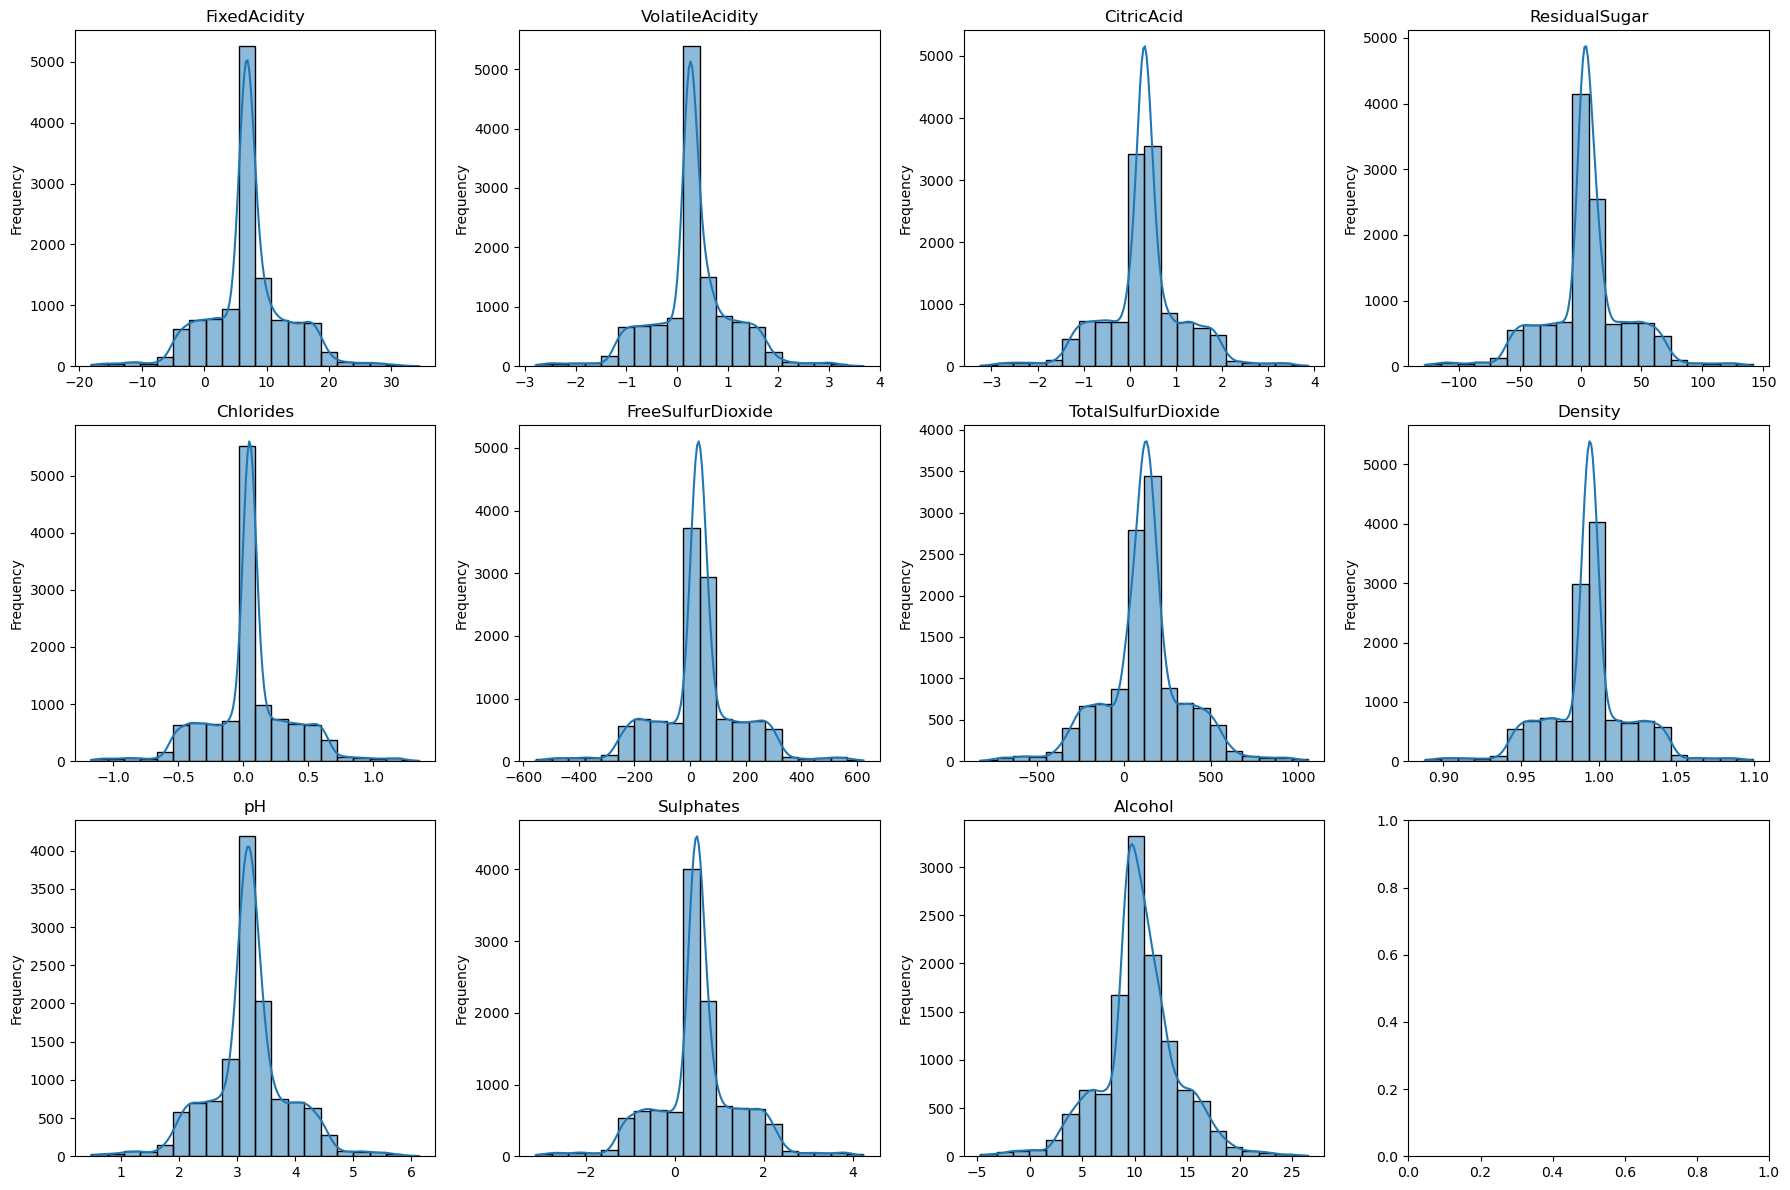

In [39]:
#EDA
continuous_vars = [
    "FixedAcidity",
    "VolatileAcidity",
    "CitricAcid",
    "ResidualSugar",
    "Chlorides",
    "FreeSulfurDioxide",
    "TotalSulfurDioxide",
    "Density",
    "pH",
    "Sulphates",
    "Alcohol"
]

# Create 3x4 grid
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

    

In [40]:
#Descriptive Stats
df.describe()




,Purchase,Cases,STARS,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex
count,12795.000000,12795.000000,9436.000000,12795.000000,12795.000000,12795.000000,12179.000000,12157.000000,12148.000000,12113.000000,12795.000000,12400.000000,11585.000000,12142.000000,12795.000000,12795.000000
mean,0.786323,3.029074,2.041755,7.075717,0.324104,0.308413,5.418733,0.054822,30.845571,120.714233,0.994203,3.207628,0.527112,10.489236,-0.009066,7.772724
std,0.409918,1.926368,0.902540,6.317643,0.784014,0.862080,33.749379,0.318467,148.714558,231.913211,0.026538,0.679687,0.932129,3.727819,0.891089,1.323926
min,0.000000,0.000000,1.000000,-18.100000,-2.790000,-3.240000,-127.800000,-1.171000,-555.000000,-823.000000,0.888090,0.480000,-3.130000,-4.700000,-2.000000,4.000000
25%,1.000000,2.000000,1.000000,5.200000,0.130000,0.030000,-2.000000,-0.031000,0.000000,27.000000,0.987720,2.960000,0.280000,9.000000,-1.000000,7.000000
50%,1.000000,3.000000,2.000000,6.900000,0.280000,0.310000,3.900000,0.046000,30.000000,123.000000,0.994490,3.200000,0.500000,10.400000,0.000000,8.000000
75%,1.000000,4.000000,3.000000,9.500000,0.640000,0.580000,15.900000,0.153000,70.000000,208.000000,1.000515,3.470000,0.860000,12.400000,1.000000,8.000000
max,1.000000,8.000000,4.000000,34.400000,3.680000,3.860000,141.150000,1.351000,623.000000,1057.000000,1.099240,6.130000,4.240000,26.500000,2.000000,17.000000


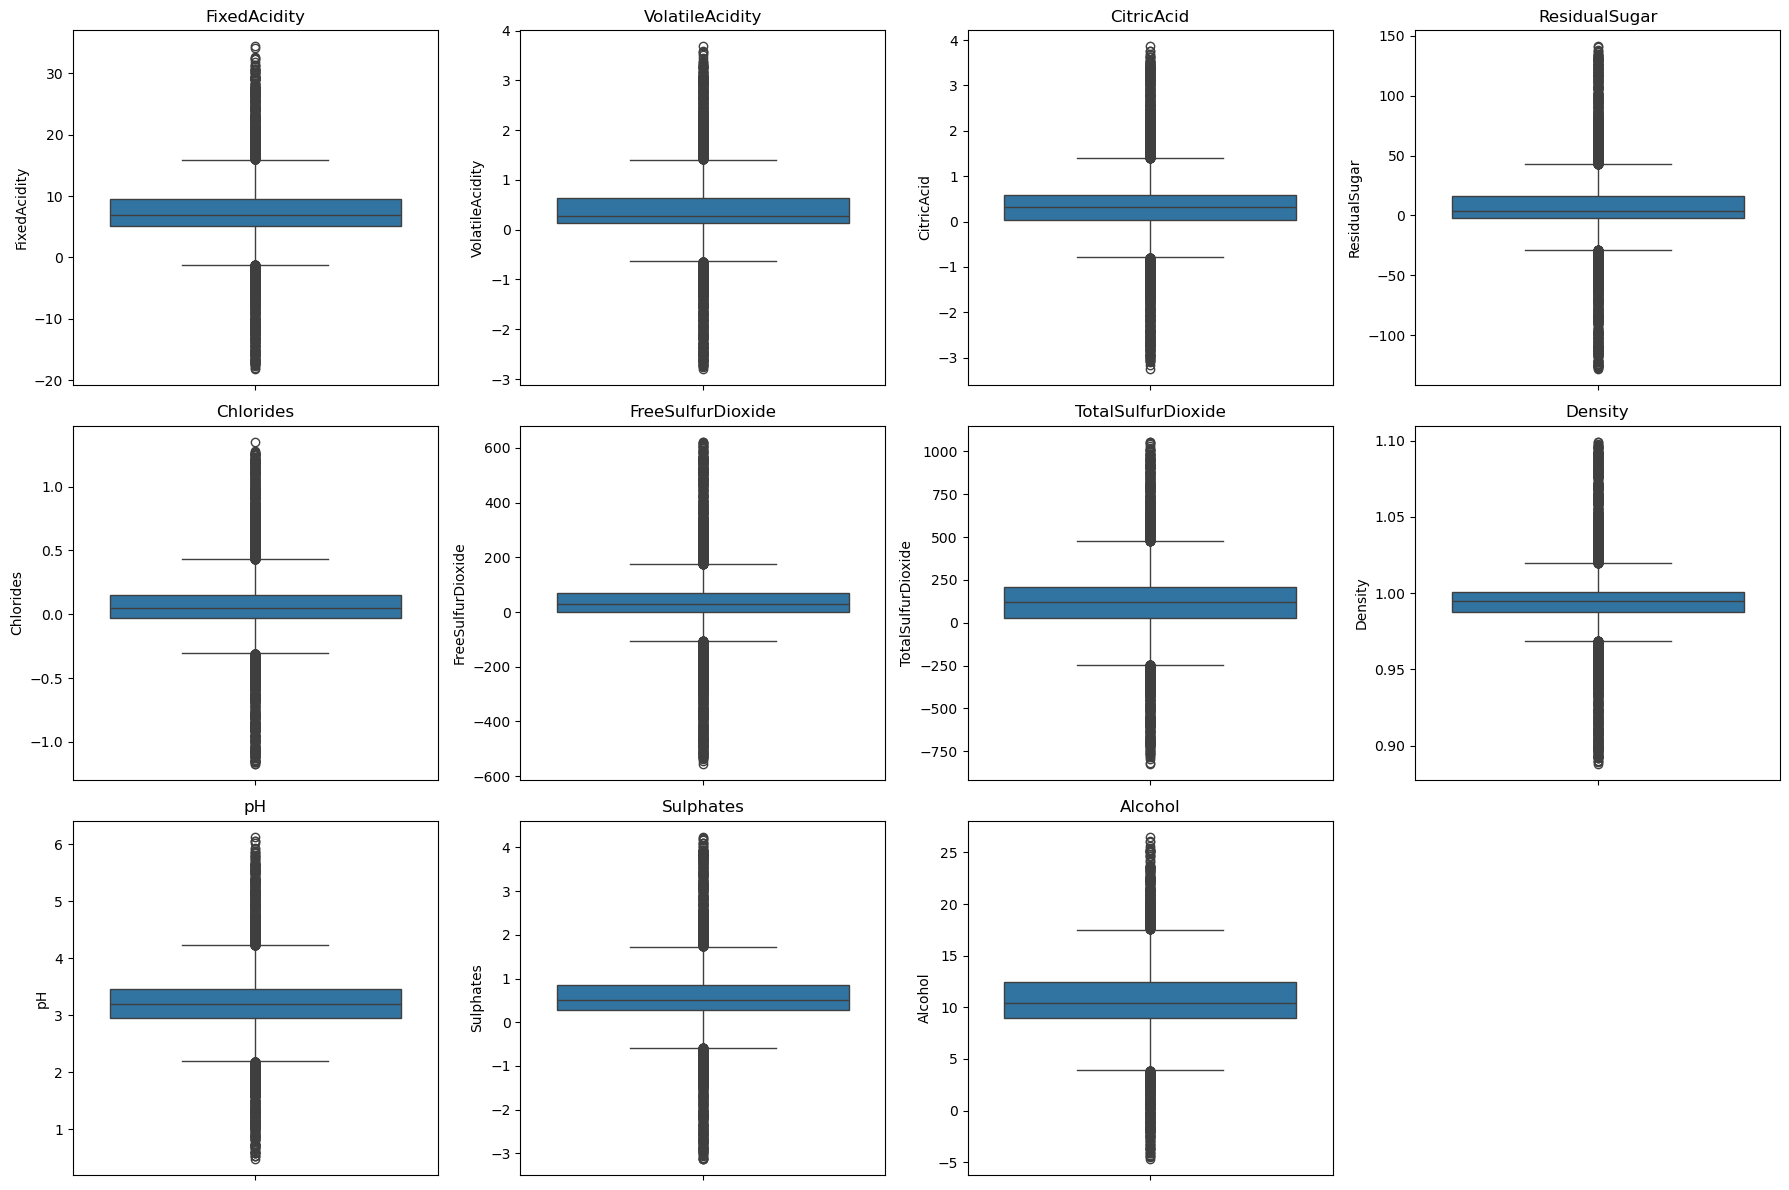

In [56]:

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    sns.boxplot(y=df[col], ax = axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(col)

# Remove empty subplots if fewer than 12 variables
for j in range(len(continuous_vars), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


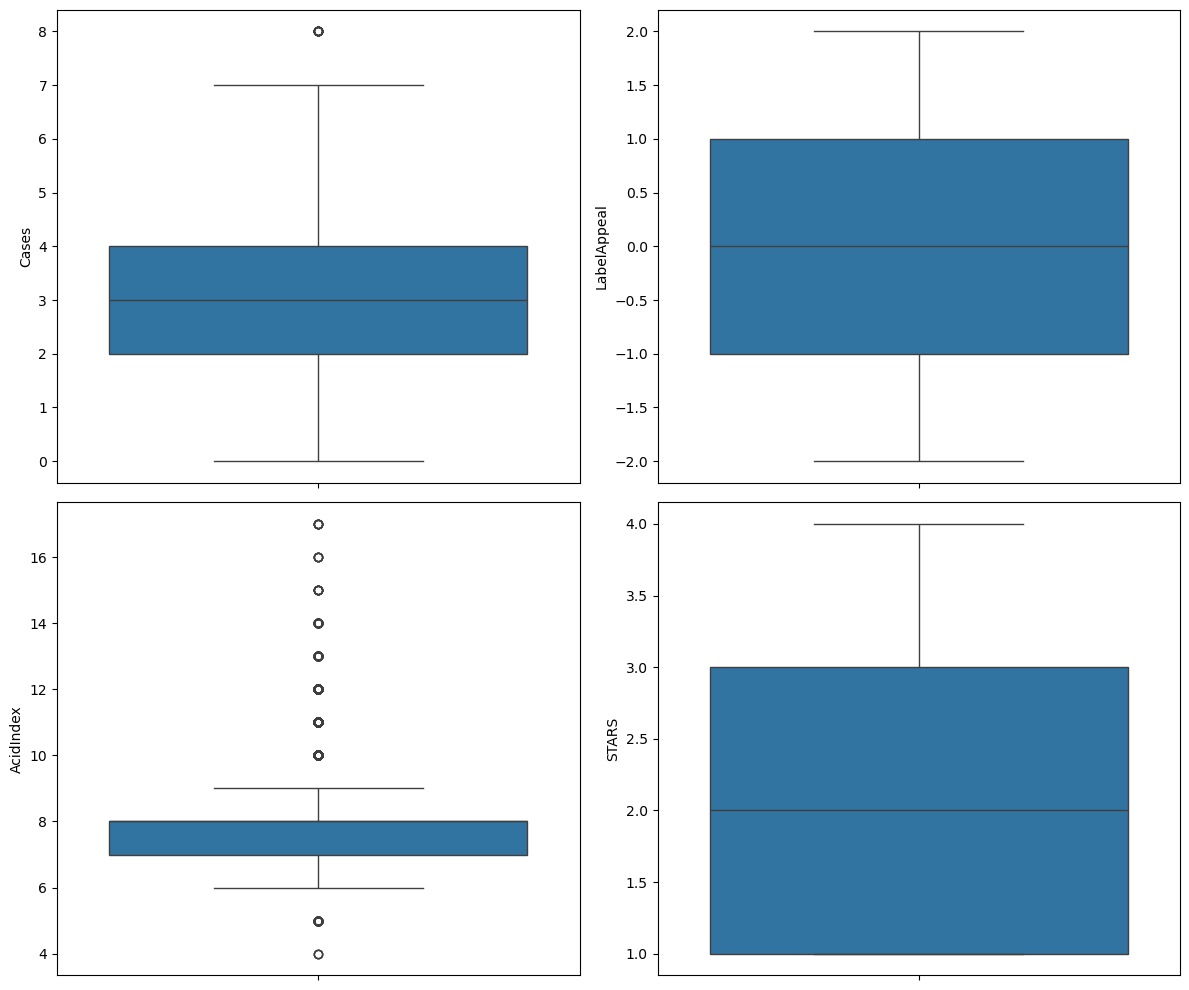

In [66]:

# List of columns you want to plot
columns = ["Cases", "LabelAppeal", "AcidIndex", "STARS"]

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # adjust size as needed

# Flatten axes array for easy iteration
axes = axes.flatten()

# Loop through each column and create countplot
for i, col in enumerate(columns):
    sns.boxplot(y=df[col], ax = axes[i])
    axes[i].set_xlabel("")


plt.tight_layout()  # adjusts spacing so titles/plots don't overlap
plt.show()

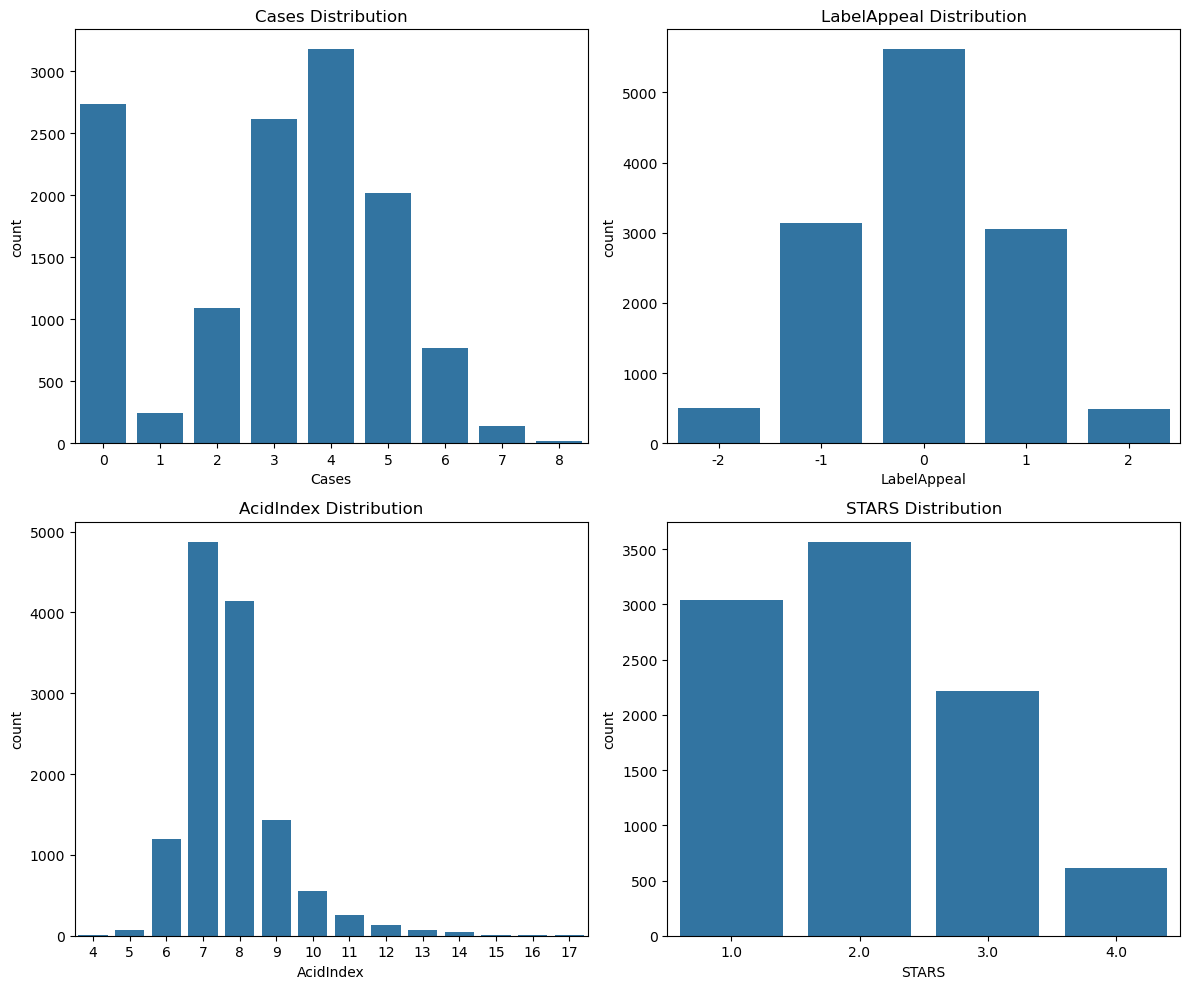

In [63]:
# List of columns you want to plot
columns = ["Cases", "LabelAppeal", "AcidIndex", "STARS"]

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # adjust size as needed

# Flatten axes array for easy iteration
axes = axes.flatten()

# Loop through each column and create countplot
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()  # adjusts spacing so titles/plots don't overlap
plt.show()

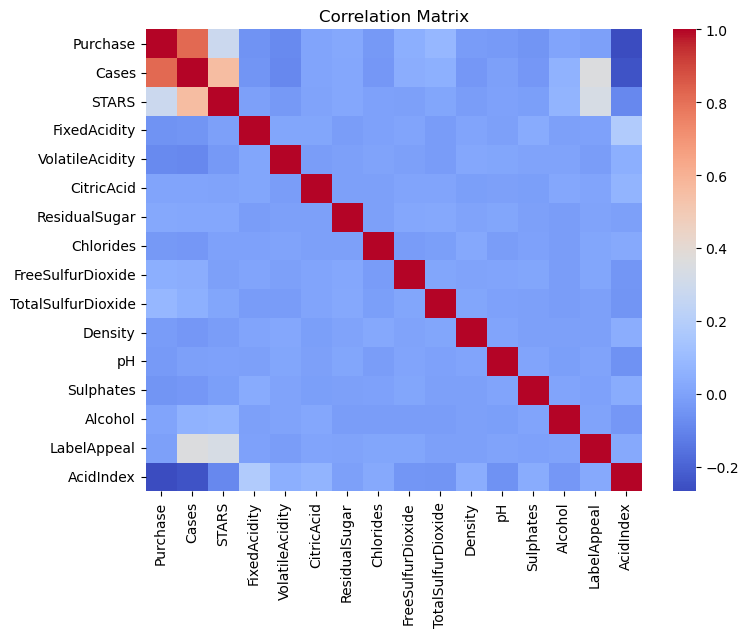

In [47]:
#Correlation
corr_matrix = df.corr(numeric_only = Trye)

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [48]:
corr_matrix["Purchase"].sort_values(ascending=False)

Purchase              1.000000
Cases                 0.819721
STARS                 0.285756
TotalSulfurDioxide    0.079805
FreeSulfurDioxide     0.045220
ResidualSugar         0.021972
Alcohol               0.008485
CitricAcid            0.005574
LabelAppeal          -0.005518
Density              -0.021262
pH                   -0.029621
Chlorides            -0.034600
Sulphates            -0.046999
FixedAcidity         -0.054299
VolatileAcidity      -0.081074
AcidIndex            -0.267793
Name: Purchase, dtype: float64

In [124]:
#Data Preparation
#Fill stars with zero or unrated
df["STARS"] = df["STARS"].fillna(0)

#Fill others with median
fill_cols = [
    "Sulphates",
    "TotalSulfurDioxide",
    "Alcohol",
    "FreeSulfurDioxide",
    "Chlorides",
    "ResidualSugar",
    "pH"
]

for col in fill_cols:
    df[col] = df[col].fillna(df[col].mean())


In [125]:
df.isna().sum().sort_values(ascending = False)

Purchase              0
Cases                 0
STARS                 0
FixedAcidity          0
VolatileAcidity       0
CitricAcid            0
ResidualSugar         0
Chlorides             0
FreeSulfurDioxide     0
TotalSulfurDioxide    0
Density               0
pH                    0
Sulphates             0
Alcohol               0
LabelAppeal           0
AcidIndex             0
dtype: int64

In [126]:
#Split into training and test set
train_df, test_df = train_test_split(df, test_size = 0.3, random_state = 42)

In [127]:
fullmodel = smf.logit(
    'Purchase ~ STARS + FixedAcidity + VolatileAcidity + CitricAcid + \
     ResidualSugar + Chlorides + FreeSulfurDioxide + TotalSulfurDioxide + \
     Density + pH + Sulphates + Alcohol + LabelAppeal + AcidIndex',
    data=train_df
).fit()

print(fullmodel.summary())
print("Log-Likelihood:", fullmodel.llf)
print(f"AIC of the model = {fullmodel.aic}")

Optimization terminated successfully.
         Current function value: 0.297256
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               Purchase   No. Observations:                 8956
Model:                          Logit   Df Residuals:                     8941
Method:                           MLE   Df Model:                           14
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                  0.4258
Time:                        15:00:48   Log-Likelihood:                -2662.2
converged:                       True   LL-Null:                       -4636.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.4037      1.316      3.347      0.001       1.825       6.983
STARS

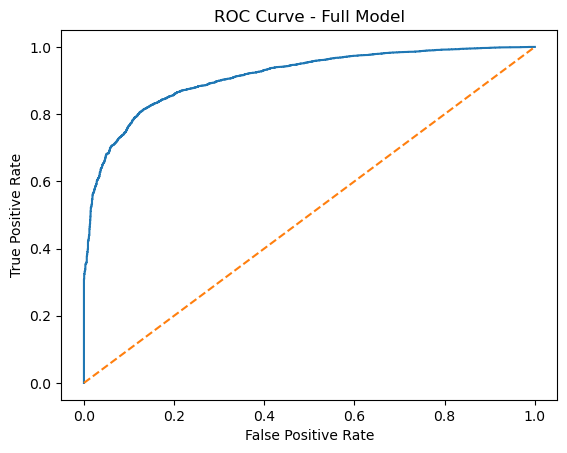

AUC (Full Model): 0.912139045790449


In [129]:
predpr = fullmodel.predict(train_df)

fpr, tpr, thresholds = roc_curve(train_df["Purchase"], predpr)
auc_value = roc_auc_score(train_df["Purchase"], predpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Full Model")
plt.show()

print("AUC (Full Model):", auc_value)

In [109]:
modelreduce = smf.logit(
    'Purchase ~ STARS + VolatileAcidity + FreeSulfurDioxide + \
     TotalSulfurDioxide + pH + Alcohol + \
     LabelAppeal + AcidIndex',
    data=train_df
).fit()

print(modelreduce.summary())
print("Log-Likelihood:", modelreduce.llf)
print("Reduced Model AIC:", modelreduce.aic)

Optimization terminated successfully.
         Current function value: 0.297984
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               Purchase   No. Observations:                 8956
Model:                          Logit   Df Residuals:                     8947
Method:                           MLE   Df Model:                            8
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                  0.4244
Time:                        13:01:32   Log-Likelihood:                -2668.7
converged:                       True   LL-Null:                       -4636.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              3.2128      0.298     10.770      0.000       2.628       3.797
STARS

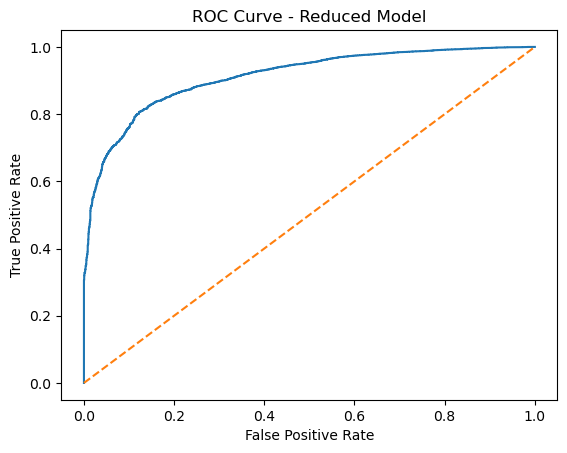

AUC (Reduced Model): 0.9117123231601586


In [130]:
predpr1 = modelreduce.predict(train_df)

fpr, tpr, thresholds = roc_curve(train_df["Purchase"], predpr1)
auc_value1 = roc_auc_score(train_df["Purchase"], predpr1)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Reduced Model")
plt.show()

print("AUC (Reduced Model):", auc_value1)

In [131]:
# Predict probabilities
test_probs = modelreduce.predict(test_df)

# Convert to 0/1
test_pred = (test_probs > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(test_df['Purchase'], test_pred))

print("Accuracy:", accuracy_score(test_df['Purchase'], test_pred))

print("AUC:", roc_auc_score(test_df['Purchase'], test_probs))

print("Precision:", precision_score(test_df['Purchase'], test_pred))

print("Recall:", recall_score(test_df['Purchase'], test_pred))

Confusion Matrix:
[[ 528  300]
 [ 264 2747]]
Accuracy: 0.8530867413388903
AUC: 0.9083814259149624
Precision: 0.9015425008204792
Recall: 0.9123214878777814


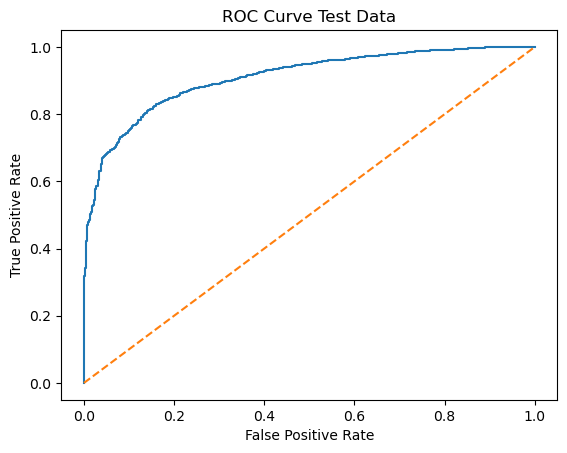

In [132]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(test_df['Purchase'], test_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Test Data")
plt.show()